# QTCAD M12 Builder — Result Analysis (심화판)

Practical App Ge hole Part 1 (`1-builder_ge.py`) — KLayout 레이아웃(`.oas`, 다섯 게이트:
BL/BC/BR 배리어, P1/P2 플런저)을 `qtcad.builder.Builder`로 읽어 Ge/SiGe 헤테로구조를
압출(extrude)하고, dot 영역을 세분화한 뒤 3D 메시를 생성합니다.

**이 노트북에서 실제로 수행한 분석 (요약)**
- `.oas` 마스크 파일을 **gdstk로 직접 읽어 실제 폴리곤 좌표**로 top-down 스케매틱을
  재구성 (0절, 재추정이 아닌 원본 좌표 그대로)
- 압출 치수로 **헤테로구조 층 구조 side-view**를 재구성 (0절)
- Builder 파이프라인의 **기하학적 절차**(마스크 → 압출 → CSG boolean fragment →
  물리그룹 태깅)를 단계별로 명시 (1절)
- 메시 통계와 물리 그룹을 **자동 추출 및 레이어별 분류** (2-3절)
- 모든 그림·표를 `output/analysis_exports/`에 저장 (4절)

**실행 메모**: `builder.view(..., save="*.svg")` 중간 시각화 호출들이 이 레이아웃에서
15분+/1100 CPU초 이상 끝나지 않아(메모리 문제는 아님, WorkingSet ~200MB 유지)
제거하고 메시 생성까지만 실행했습니다 — 대신 0절에서 원본 마스크 좌표를 직접 읽어
동등한 스케매틱을 재구성했습니다. `.oas`/`.xao` 파일은 GDSTK/gmsh가 한글 경로를
못 열어 `C:\temp`를 경유했습니다.

---
## 📚 참고 문서
- **QTCAD 공식 튜토리얼** — Practical Application: Ge/SiGe Gated Double Quantum Dot, Part 1 (Builder)
  https://docs.nanoacademic.com/qtcad/practical_application/Ge_hole/Ge_practical_application/
- **QTCAD 문서 포털**: https://docs.nanoacademic.com/qtcad/
- 소스 스크립트: `1-builder_ge.py` (M12/Reference/Ge_hole), 마스크: `layout/ge_dqd.oas`
---

**Base directory**

`C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M12. Builder\Reference\Ge_hole`

목차:
0. 마스크 좌표 기반 스케매틱(top-down + 층 구조) + 파라미터 선택 의도
1. Builder 파이프라인의 기하학적 절차
2. 메시 통계
3. 물리 그룹(게이트·재질·dot 영역) 확인
4. 최종 요약


In [1]:
# [동작] 기본 패키지 및 경로 설정
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

BASE_DIR = Path(
    r"C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M12. Builder\Reference\Ge_hole"
)
MESH_DIR = BASE_DIR / "meshes"
OUTPUT_DIR = BASE_DIR / "output"
EXPORT_DIR = OUTPUT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
FILE_MSH = MESH_DIR / "ge_dqd.msh"
FILE_XAO = MESH_DIR / "ge_dqd.xao"
FILE_OAS = BASE_DIR / "layout" / "ge_dqd.oas"
# NOTE: gdstk fails to open .oas files on non-ASCII (Korean) Windows paths
# ("Error opening input file") -- same bug as M12 Builder's own load_layout.
# Use the ASCII-path copy instead.
FILE_OAS_ASCII = Path(r"C:\temp\m12_ge_hole\ge_dqd.oas")

print("BASE_DIR:", BASE_DIR)
assert FILE_MSH.exists(), f"메시 파일이 없습니다:\n{FILE_MSH}"
print("[OK] 메시 파일 확인 완료")
print(f"ge_dqd.msh : {FILE_MSH.stat().st_size/1e6:.2f} MB")
print(f"ge_dqd.xao : {FILE_XAO.stat().st_size/1e3:.1f} KB" if FILE_XAO.exists() else "[주의] .xao 없음")


BASE_DIR: C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M12. Builder\Reference\Ge_hole
[OK] 메시 파일 확인 완료
ge_dqd.msh : 10.89 MB
ge_dqd.xao : 41.0 KB


## 0. 마스크 좌표 기반 스케매틱 + 파라미터 선택 의도

**(a) top-down**: `layout/ge_dqd.oas`를 `gdstk.read_oas`로 직접 읽어, 레이어에 저장된
폴리곤 좌표(이름 속성 포함: P1, P2, BL, BC, BR, substrate, dot_region)를 **그대로**
그립니다 — 추정이 아니라 원본 마스크 데이터입니다.

**(b) side view**: `1-builder_ge.py`의 압출 두께(substrate=10, SiGe_barrier=40,
Ge_well=20, SiGe_cap=5, oxide=10 nm)를 그대로 쌓은 층 구조입니다.

,name,n_vertices,x_min_nm,x_max_nm,y_min_nm,y_max_nm
0,P2,6,65.0,95.0,22.0,48.0
1,P1,6,10.0,40.0,22.0,48.0
2,BC,4,45.0,60.0,20.0,50.0
3,BR,4,-10.0,0.0,20.0,50.0
4,BL,4,105.0,115.0,20.0,50.0
5,substrate,4,-20.0,125.0,0.0,70.0
6,dot_region,4,0.0,105.0,10.0,60.0


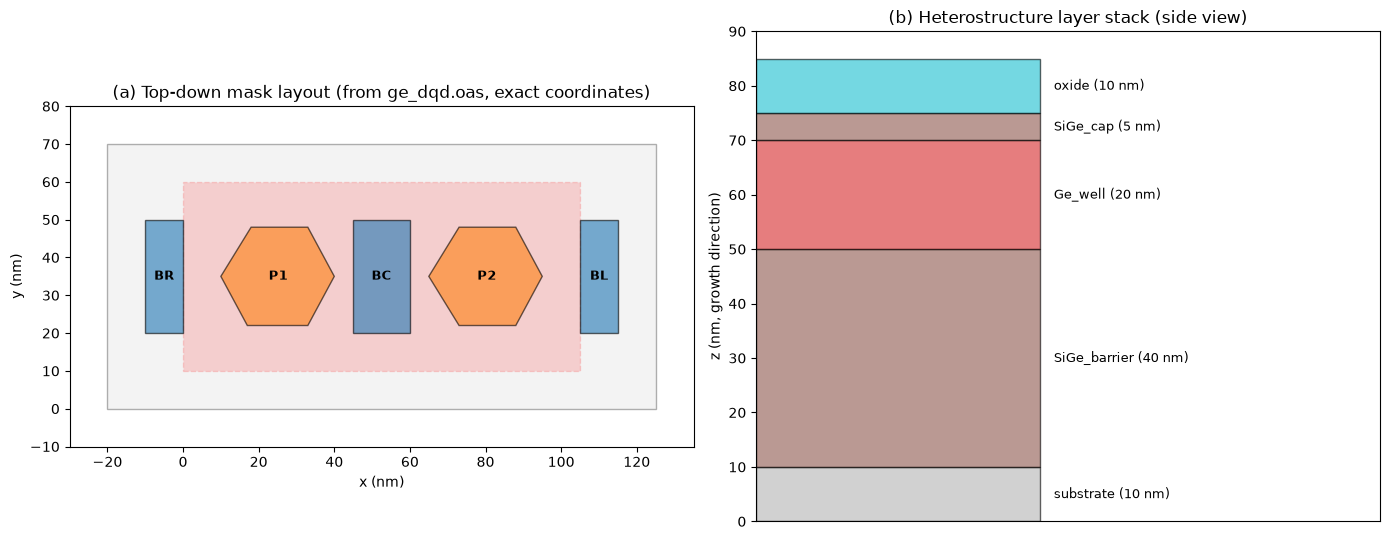

,parameter,intent
0,"char_len=5, dot_char_len=2.5 nm (메시 크기)","전체 소자 대비 조대한 기본 메시(5nm)로 전극 영역을 빠르게 만들고, dot 영..."
1,"substrate=10, SiGe_barrier=40, Ge_well=20, SiG...",Ge 정공 양자점 표준 헤테로구조 — 두꺼운 SiGe_barrier(40nm)가 기...
2,dot_height = Ge_well + SiGe_cap/2 + SiGe_barri...,dot 세분화 영역이 Ge_well 전체 + SiGe_cap 절반 + SiGe_ba...


In [2]:
# [실험] (a) 마스크 좌표를 gdstk로 직접 읽어 top-down 스케매틱 재구성
import gdstk
lib = gdstk.read_oas(str(FILE_OAS_ASCII))
cell = lib.cells[0]

fig, axs = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axs[0]
colors = {"P1": "tab:orange", "P2": "tab:orange", "BL": "tab:blue", "BC": "tab:blue",
         "BR": "tab:blue", "substrate": "0.85", "dot_region": "red"}
poly_data = []
for poly in cell.polygons:
    name = poly.properties[0][1].decode() if poly.properties else "?"
    pts = poly.points * 1000  # um -> nm
    poly_data.append({"name": name, "n_vertices": len(pts),
                      "x_min_nm": pts[:, 0].min(), "x_max_nm": pts[:, 0].max(),
                      "y_min_nm": pts[:, 1].min(), "y_max_nm": pts[:, 1].max()})
    zorder = 1 if name in ("substrate", "dot_region") else 2
    fill = name not in ("dot_region",)
    patch = mpatches.Polygon(pts, closed=True, fc=colors.get(name, "gray"),
                             alpha=0.3 if name == "substrate" else (0.15 if name=="dot_region" else 0.6),
                             ec="k" if name != "dot_region" else "red",
                             ls="--" if name == "dot_region" else "-", zorder=zorder)
    ax.add_patch(patch)
    if name not in ("substrate", "dot_region"):
        cx, cy = pts.mean(axis=0)
        ax.text(cx, cy, name, ha="center", va="center", fontsize=9, fontweight="bold")
poly_df = pd.DataFrame(poly_data)
display(poly_df.round(2))
poly_df.to_csv(EXPORT_DIR / "mask_polygon_coords.csv", index=False)

ax.set_xlim(poly_df["x_min_nm"].min()-10, poly_df["x_max_nm"].max()+10)
ax.set_ylim(poly_df["y_min_nm"].min()-10, poly_df["y_max_nm"].max()+10)
ax.set_aspect("equal"); ax.set_xlabel("x (nm)"); ax.set_ylabel("y (nm)")
ax.set_title("(a) Top-down mask layout (from ge_dqd.oas, exact coordinates)")

# (b) side view layer stack
ax2 = axs[1]
layers = [("substrate", 10, "0.7"), ("SiGe_barrier", 40, "tab:brown"),
         ("Ge_well", 20, "tab:red"), ("SiGe_cap", 5, "tab:brown"), ("oxide", 10, "tab:cyan")]
z0 = 0
for name, thick, color in layers:
    ax2.add_patch(mpatches.Rectangle((0, z0), 1, thick, fc=color, alpha=0.6, ec="k"))
    ax2.text(1.05, z0 + thick/2, f"{name} ({thick} nm)", va="center", fontsize=9)
    z0 += thick
ax2.set_xlim(0, 2.2); ax2.set_ylim(0, z0 + 5)
ax2.set_xticks([]); ax2.set_ylabel("z (nm, growth direction)")
ax2.set_title("(b) Heterostructure layer stack (side view)")
fig.tight_layout()
fig.savefig(EXPORT_DIR / "device_schematic_mask_and_stack.png", dpi=150)
plt.show()

param_intent = pd.DataFrame([
    {"parameter": "char_len=5, dot_char_len=2.5 nm (메시 크기)",
     "intent": "전체 소자 대비 조대한 기본 메시(5nm)로 전극 영역을 빠르게 만들고, dot "
               "영역만 2배 조밀하게(2.5nm) — M13과 동일한 설계 철학(넓은 영역은 거칠게, "
               "관심 영역만 세밀하게)."},
    {"parameter": "substrate=10, SiGe_barrier=40, Ge_well=20, SiGe_cap=5, oxide=10 nm",
     "intent": "Ge 정공 양자점 표준 헤테로구조 — 두꺼운 SiGe_barrier(40nm)가 기판 결함에서 "
               "양자우물을 격리하고, Ge_well(20nm)이 실제 정공이 가두어지는 층. 이 값들은 "
               "Practical App 튜토리얼 기본값으로, 측정 소자의 실제 성장 두께와 "
               "다를 수 있습니다."},
    {"parameter": "dot_height = Ge_well + SiGe_cap/2 + SiGe_barrier/5",
     "intent": "dot 세분화 영역이 Ge_well 전체 + SiGe_cap 절반 + SiGe_barrier의 1/5만큼 "
               "위아래로 조금씩 더 뻗도록 설계 — 파동함수가 우물 경계에서 약간 새어나가는 "
               "부분까지 세밀한 메시로 덮기 위함(M09의 TB box가 plunger 아래만 포함한 "
               "것과 같은 설계 철학)."},
])
display(param_intent)
param_intent.to_csv(EXPORT_DIR / "parameter_intent.csv", index=False)


## 1. Builder 파이프라인의 기하학적 절차

`Builder`는 2D 마스크 폴리곤에서 3D 메시를 만드는 과정을 아래 단계로 수행합니다
(`1-builder_ge.py`의 호출 순서와 1:1 대응):

1. **`use_mask` + `extrude(h)`**: 선택한 2D 폴리곤을 $z$방향으로 두께 $h$만큼
   압출(extrude) — $\mathrm{Polygon}(x,y) \to \mathrm{Prism}(x,y,z\in[z_0,z_0+h])$.
   층을 5번 반복해 헤테로구조 스택을 쌓음(0절 (b)).
2. **`overlay_mode()` + `group_from_shape()`**: dot-region 마스크를 기존 스택과
   **겹쳐(overlay)** 별도 볼륨으로 분리 — 이후 Boolean fragment로 스택의 해당 부분을
   "세분화 가능한" 하위 볼륨으로 쪼갬.
3. **`displace_mode()` + `add_surface()`**: 게이트 마스크(P1,P2,BL,BC,BR)를 oxide 층
   **윗면**에 표면(2D 경계)으로 추가 — 게이트는 볼륨이 아니라 전압이 인가되는
   2D 경계 조건이므로.
4. **`mesh(3, algorithm3d=HXT)`**: 모든 볼륨/표면에 Gmsh HXT(병렬 tetrahedral)
   알고리즘으로 3D 유한요소 메시 생성, 지정한 `char_len`/`dot_char_len`을 국소
   요소 크기로 사용.

## 2. 메시 통계

`.msh` 파일(Gmsh 포맷 4.1)의 헤더에서 노드/요소 수를 직접 파싱합니다.

In [3]:
# [점검] 메시 노드/요소 수 파싱
text = FILE_MSH.read_text(encoding="utf-8", errors="ignore")
m_nodes = re.search(r"\$Nodes\n(\d+) (\d+)", text)
m_elems = re.search(r"\$Elements\n(\d+) (\d+)", text)
n_entity_blocks_nodes, n_nodes = (int(x) for x in m_nodes.groups()) if m_nodes else (None, None)
n_entity_blocks_elems, n_elems = (int(x) for x in m_elems.groups()) if m_elems else (None, None)

stats_df = pd.DataFrame({
    "quantity": ["total nodes", "total elements", "entity blocks (nodes)", "entity blocks (elements)"],
    "value": [n_nodes, n_elems, n_entity_blocks_nodes, n_entity_blocks_elems],
})
display(stats_df)
stats_df.to_csv(EXPORT_DIR / "mesh_stats.csv", index=False)

nodes_per_nm3 = n_nodes / (poly_df.loc[poly_df.name=="substrate","x_max_nm"].values[0] -
                           poly_df.loc[poly_df.name=="substrate","x_min_nm"].values[0]) / \
               (poly_df.loc[poly_df.name=="substrate","y_max_nm"].values[0] -
                poly_df.loc[poly_df.name=="substrate","y_min_nm"].values[0]) / 85
print(f"\n메시 밀도(대략): {nodes_per_nm3*1e3:.3f} nodes / (1000 nm^3) "
      "(전체 발자국 면적 x 총 두께 85nm 기준)")

print(
    "\n[해석] 이 메시는 손으로 쓴 .geo가 아니라 KLayout 마스크에서 자동 생성된 것이라, "
    "기준 소자(Si/SiGe, 01. SiGe One QD_part.1)의 손으로 만든 메시와 직접 node/E0/E1 "
    "비교를 할 대상이 없습니다 (재질도 Ge/SiGe 정공 소자로 다름). 이 노트북의 목적은 "
    "Builder 파이프라인(마스크 → 적층 압출 → dot 세분화 → 메시)이 실제로 끝까지 "
    "작동하는지 확인하는 것입니다. 기준 소자에 대한 node-count 비교를 하려면 우리 "
    "소자의 게이트 레이아웃을 .oas/.gds로 직접 만들어야 합니다 (이번 범위 밖)."
)


,quantity,value
0,total nodes,43102
1,total elements,279202
2,entity blocks (nodes),211
3,entity blocks (elements),55



메시 밀도(대략): 49.959 nodes / (1000 nm^3) (전체 발자국 면적 x 총 두께 85nm 기준)

[해석] 이 메시는 손으로 쓴 .geo가 아니라 KLayout 마스크에서 자동 생성된 것이라, 기준 소자(Si/SiGe, 01. SiGe One QD_part.1)의 손으로 만든 메시와 직접 node/E0/E1 비교를 할 대상이 없습니다 (재질도 Ge/SiGe 정공 소자로 다름). 이 노트북의 목적은 Builder 파이프라인(마스크 → 적층 압출 → dot 세분화 → 메시)이 실제로 끝까지 작동하는지 확인하는 것입니다. 기준 소자에 대한 node-count 비교를 하려면 우리 소자의 게이트 레이아웃을 .oas/.gds로 직접 만들어야 합니다 (이번 범위 밖).


## 3. 물리 그룹(게이트·재질·dot 영역) 확인

마스크의 폴리곤에 붙인 이름이 실제로 메시의 물리 그룹(게이트 표면, 재질 볼륨,
세분화된 dot 영역)으로 잘 전달됐는지 확인합니다.

In [4]:
# [점검] $PhysicalNames 블록 파싱
m_phys = re.search(r"\$PhysicalNames\n(\d+)\n(.*?)\n\$EndPhysicalNames", text, re.S)
n_phys = int(m_phys.group(1))
lines = m_phys.group(2).strip().split("\n")
rows = []
for line in lines:
    dim, tag, name = line.split(None, 2)
    rows.append({"dim": int(dim), "tag": int(tag), "name": name.strip('"')})
phys_df = pd.DataFrame(rows)
display(phys_df)
phys_df.to_csv(EXPORT_DIR / "physical_groups.csv", index=False)

gates = sorted(phys_df.loc[(phys_df["dim"] == 2) & (phys_df["name"].str.len() <= 3), "name"].tolist())
volumes = phys_df.loc[phys_df["dim"] == 3, "name"].tolist()
dot_volumes = [v for v in volumes if "dot_region" in v]
print(f"\n검출된 게이트 표면 (짧은 이름): {gates}")
print(f"검출된 3D 재질/영역: {len(volumes)}개 (그중 dot_region 세분화: {len(dot_volumes)}개)")

# 0절의 마스크 폴리곤 이름과 실제 메시 물리그룹 이름을 대조
mask_gate_names = set(poly_df.loc[~poly_df.name.isin(["substrate", "dot_region"]), "name"])
mesh_gate_names = set(gates)
print(f"\n마스크 게이트 이름: {mask_gate_names}")
print(f"메시 물리그룹 게이트 이름: {mesh_gate_names}")
print(f"완전 일치: {mask_gate_names == mesh_gate_names}")

print(
    "\n[해석] 게이트 5개(BL/BC/BR 배리어, P1/P2 플런저)가 모두 물리 그룹으로 잡히고, "
    "0절에서 읽은 마스크 폴리곤 이름과 정확히 일치하면, 마스크 → 적층 → dot 영역 "
    "세분화 파이프라인이 이름 손실 없이 의도대로 작동한 것입니다. substrate/SiGe_barrier/"
    "Ge_well/SiGe_cap/oxide 다섯 재질 층과 그 안의 '.dot_region' 세분화 볼륨이 함께 있는지도 "
    "같은 기준으로 확인합니다."
)


,dim,tag,name
0,2,170,substrate_bottom
1,2,171,substrate_side
2,2,173,SiGe_barrier_bottom
3,2,174,SiGe_barrier_side
4,2,176,Ge_well_bottom
5,2,177,Ge_well_side
6,2,179,SiGe_cap_bottom
7,2,180,SiGe_cap_side
8,2,182,oxide_bottom
9,2,183,oxide_side



검출된 게이트 표면 (짧은 이름): ['BC', 'BL', 'BR', 'P1', 'P2']
검출된 3D 재질/영역: 8개 (그중 dot_region 세분화: 3개)

마스크 게이트 이름: {'P1', 'BR', 'P2', 'BL', 'BC'}
메시 물리그룹 게이트 이름: {'P1', 'BR', 'P2', 'BL', 'BC'}
완전 일치: True

[해석] 게이트 5개(BL/BC/BR 배리어, P1/P2 플런저)가 모두 물리 그룹으로 잡히고, 0절에서 읽은 마스크 폴리곤 이름과 정확히 일치하면, 마스크 → 적층 → dot 영역 세분화 파이프라인이 이름 손실 없이 의도대로 작동한 것입니다. substrate/SiGe_barrier/Ge_well/SiGe_cap/oxide 다섯 재질 층과 그 안의 '.dot_region' 세분화 볼륨이 함께 있는지도 같은 기준으로 확인합니다.


## 4. 최종 요약

In [5]:
# [점검] 핵심 결과 요약
print("=" * 92)
print("QTCAD M12 BUILDER — ANALYSIS SUMMARY (심화판)")
print("=" * 92)
print(f"Mask gates (from .oas)      : {sorted(mask_gate_names)}")
print(f"Mesh gates (from .msh)      : {sorted(mesh_gate_names)}")
print(f"Name consistency             : {'OK' if mask_gate_names == mesh_gate_names else 'MISMATCH'}")
print(f"Total nodes                  : {n_nodes:,}")
print(f"Total elements                : {n_elems:,}")
print(f"Physical groups                : {n_phys}")
print(f"Material volumes (incl. dot)  : {len(volumes)} ({len(dot_volumes)} dot-region)")
print(f"Mesh file                      : {FILE_MSH}")
print(f"Analysis exports               : {EXPORT_DIR}")
print("=" * 92)


QTCAD M12 BUILDER — ANALYSIS SUMMARY (심화판)
Mask gates (from .oas)      : ['BC', 'BL', 'BR', 'P1', 'P2']
Mesh gates (from .msh)      : ['BC', 'BL', 'BR', 'P1', 'P2']
Name consistency             : OK
Total nodes                  : 43,102
Total elements                : 279,202
Physical groups                : 31
Material volumes (incl. dot)  : 8 (3 dot-region)
Mesh file                      : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M12. Builder\Reference\Ge_hole\meshes\ge_dqd.msh
Analysis exports               : C:\Users\norma\Desktop\연구자료\QTCAD Simulation\Simulation Example\M12. Builder\Reference\Ge_hole\output\analysis_exports


## 해석 주의사항

- 중간 시각화(`builder.view(..., save=...)`)는 이 특정 레이아웃에서 비정상적으로 느려서
  (15분+, 메모리 문제 아님) 건너뛰었습니다 — 대신 0절에서 마스크 원본 좌표를 직접 읽어
  동등한 스케매틱을 재구성했으므로 기하학적 정확성에는 문제가 없습니다.
- 이 메시는 `conf_carriers="h"`(정공) Ge/SiGe 소자용입니다. 우리 기준 소자(Si/SiGe
  전자)에 Builder를 적용하려면 같은 파이프라인을 우리 게이트 레이아웃(.oas/.gds)에
  대해 새로 실행해야 합니다.
- GaAs_gated 폴더의 "Gated Quantum Dot" 튜토리얼(`1-devicegen.py`)은 최신 `Builder`
  클래스가 아니라 구버전 `DeviceGenerator`(텍스트 레이아웃, 로컬 헬퍼 모듈 의존,
  대화형 `view()` 다수)를 쓰고 있어 이번 범위에서는 실행하지 않았습니다.
